# Multimodal AI

## Image and Text - CLIP

![CLIP Overview](https://raw.githubusercontent.com/openai/CLIP/main/CLIP.png)
**CLIP (Contrastive Language–Image Pretraining)** is a model introduced by OpenAI that learns to connect images and text by projecting them into a shared embedding space. It is trained on 400 million (image, text) pairs collected from the internet.

CLIP forms the basis of most of the modern SOTA Text to Image Genration Pipelines. Why ? Because it contains rich text to image and image to text information useful for diverse other tasks.

In this section lets dive into -
- Understanding of Image and Text Encoders of CLIP.
- Zero Shot Classification using similarity measures.


In [ ]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import requests
from io import BytesIO
import matplotlib.pyplot as plt

In [ ]:
# Load CLIP model
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

In [ ]:
url_dog = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
url_car = "https://images.pexels.com/photos/170811/pexels-photo-170811.jpeg"

# Fetch the image from the web
response1 = requests.get(url_dog)
image_dog = Image.open(BytesIO(response1.content))

response2 = requests.get(url_car)
image_car = Image.open(BytesIO(response2.content))

image = image_dog

In [ ]:
def show_image(image):
  plt.imshow(image)
  plt.axis("off")
  plt.show()

In [ ]:
show_image(image_dog)

In [ ]:
show_image(image_car)

In [ ]:
image_inputs = processor(images=image_dog, return_tensors="pt")
with torch.no_grad():
    image_embeds = model.get_image_features(**image_inputs)
image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)

print(f"Image embedding shape: {image_embeds.shape}")

In [ ]:
texts = ["an image of two dogs sitting on a grassy field with orange flowers",
         "an image of a cat drinking milk sitting on a table",
         "a photo of a blue car in the street"]

# preprocess text
text_inputs = processor(text=texts, return_tensors="pt", padding=True)

# encode text
with torch.no_grad():
    text_embeds = model.get_text_features(**text_inputs)

# normalize
text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

print(f"Text embeddings shape: {text_embeds.shape}")

In [ ]:
similarities = (image_embeds @ text_embeds.T).squeeze()

# sort and print
sorted_indices = similarities.argsort(descending=True)

print("\nResults:")
for idx in sorted_indices:
    print(f"Text: {texts[idx]} \t Similarity: {similarities[idx].item():.4f}")

In [ ]:
print(similarities.shape)

## Whisper: Automatic Speech Recognition & Translation

**Whisper** is an automatic speech recognition (ASR) model released by OpenAI. It’s trained on **680,000 hours of multilingual and multitask supervised data** collected from the web.  

Key highlights:

- Supports **99 languages**
- Transcribes speech into text
- Can **translate non-English speech to English**
- Handles noisy or accented speech surprisingly well

Whisper models:
- small → fast but less accurate
- medium → balanced
- large → highest accuracy but slower

In this notebook, we’ll transcribe audio in:
- English
- Hindi
- Spanish

Whisper brings powerful speech capabilities to multimodal AI systems!


In [ ]:
!pip install -U openai-whisper

In [ ]:
!wget https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/1.flac
!wget https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/4.flac

In [ ]:
import whisper
model = whisper.load_model("small")

In [ ]:
result = model.transcribe("/content/1.flac")
print(result["text"])

In [ ]:
# prompt: play the audio file

from IPython.display import Audio, display
display(Audio("/content/1.flac", autoplay=True))

In [ ]:
display(Audio("/content/4.flac", autoplay=True))

In [ ]:
# load audio and pad/trim it to fit 30 seconds
audio = whisper.load_audio("/content/4.flac")
audio = whisper.pad_or_trim(audio)

# make log-Mel spectrogram and move to the same device as the model
mel = whisper.log_mel_spectrogram(audio, n_mels=model.dims.n_mels).to(model.device)

# detect the spoken language
_, probs = model.detect_language(mel)
print(f"Detected language: {max(probs, key=probs.get)}")

# decode the audio
options = whisper.DecodingOptions()
result = whisper.decode(model, mel, options)

# print the recognized text
print(result.text)

## The World of Multimedia

##SyncNet

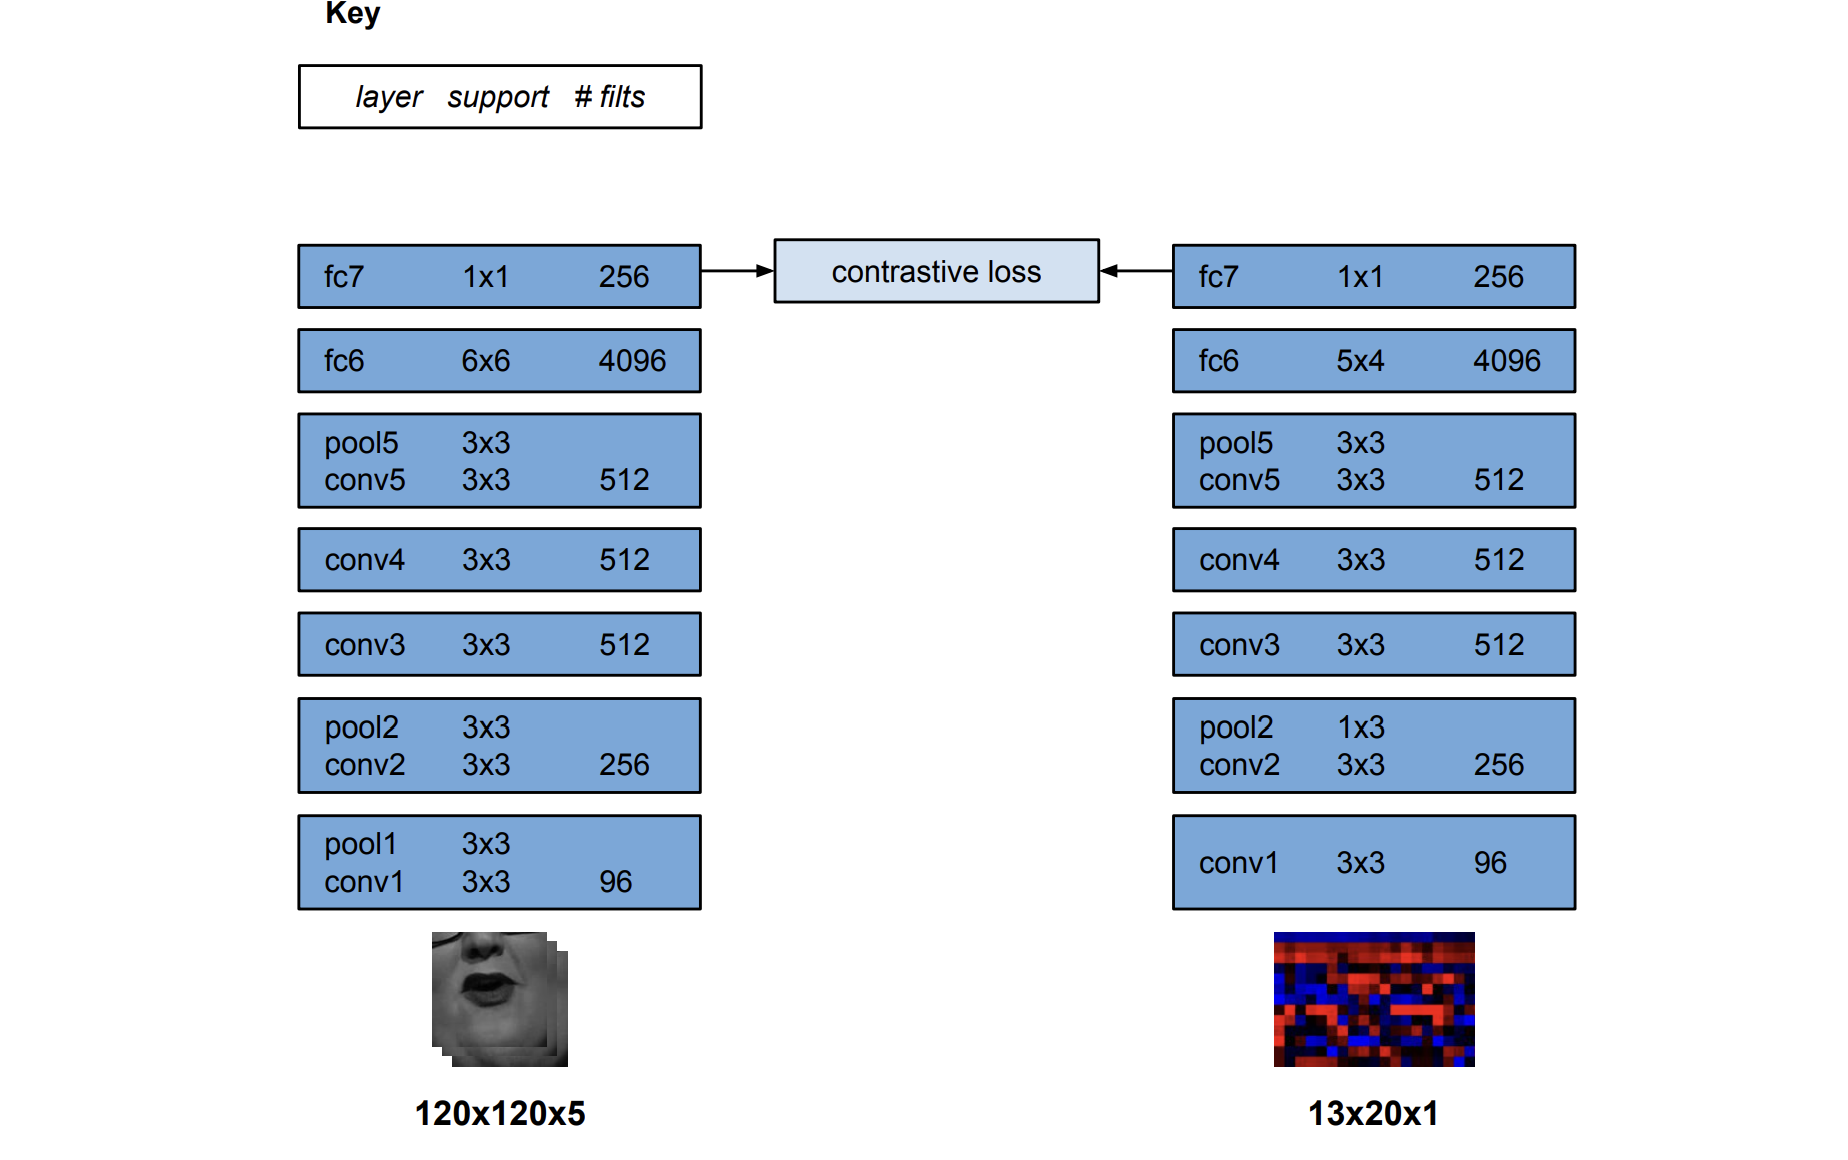

🔍 **What is SyncNet?**

SyncNet is a deep learning model that checks whether a video’s audio matches the person’s lip movements—basically, if the sound is in sync with what the person is saying on screen.

🎯 **Purpose of SyncNet**

The main goal of SyncNet is to detect audio-visual sync. It’s useful for:

1. Lip-sync detection – Checking if the audio matches the video.
2. Speaker verification – Figuring out who is speaking, especially in videos with multiple people.
3. Fake video detection – Spotting deepfakes or edited videos where audio might not match the speaker.

🛠️ **How It Works (Simplified)**

1. Input:

  - It takes a short video clip (like 0.2 seconds) and extracts:

  - A clip of the person’s face (especially the mouth area).

  - The audio of what’s being said at that moment.

2. Processing:

  - The model turns both the visual info (lip movement) and audio info (sound waves) into numbers using deep neural networks.

  - Then it compares them to see if they “match.”

3. Output: It gives a similarity score—a high score means the lips and audio are in sync.

In [ ]:
!git clone https://github.com/joonson/syncnet_python.git

In [ ]:
%cd syncnet_python
!pip install -r requirements.txt

!wget https://www.johnvansickle.com/ffmpeg/old-releases/ffmpeg-4.4-amd64-static.tar.xz
!tar -xf ffmpeg-4.4-amd64-static.tar.xz
!export FFMPEG_PATH=/content/syncnet_python/ffmpeg-4.4-amd64-static

!mkdir data
!wget http://www.robots.ox.ac.uk/~vgg/software/lipsync/data/example.avi -O data/example.avi

!mkdir detectors/s3fd/weights
!wget https://www.robots.ox.ac.uk/~vgg/software/lipsync/data/sfd_face.pth -O detectors/s3fd/weights/sfd_face.pth


In [ ]:
!wget http://www.robots.ox.ac.uk/~vgg/software/lipsync/data/syncnet_v2.model -O data/syncnet_v2.model

In [ ]:
%cd /content/syncnet_python
!python demo_syncnet.py --videofile /content/syncnet_python/data/example.avi --tmp_dir /content/

## Wav2Lip
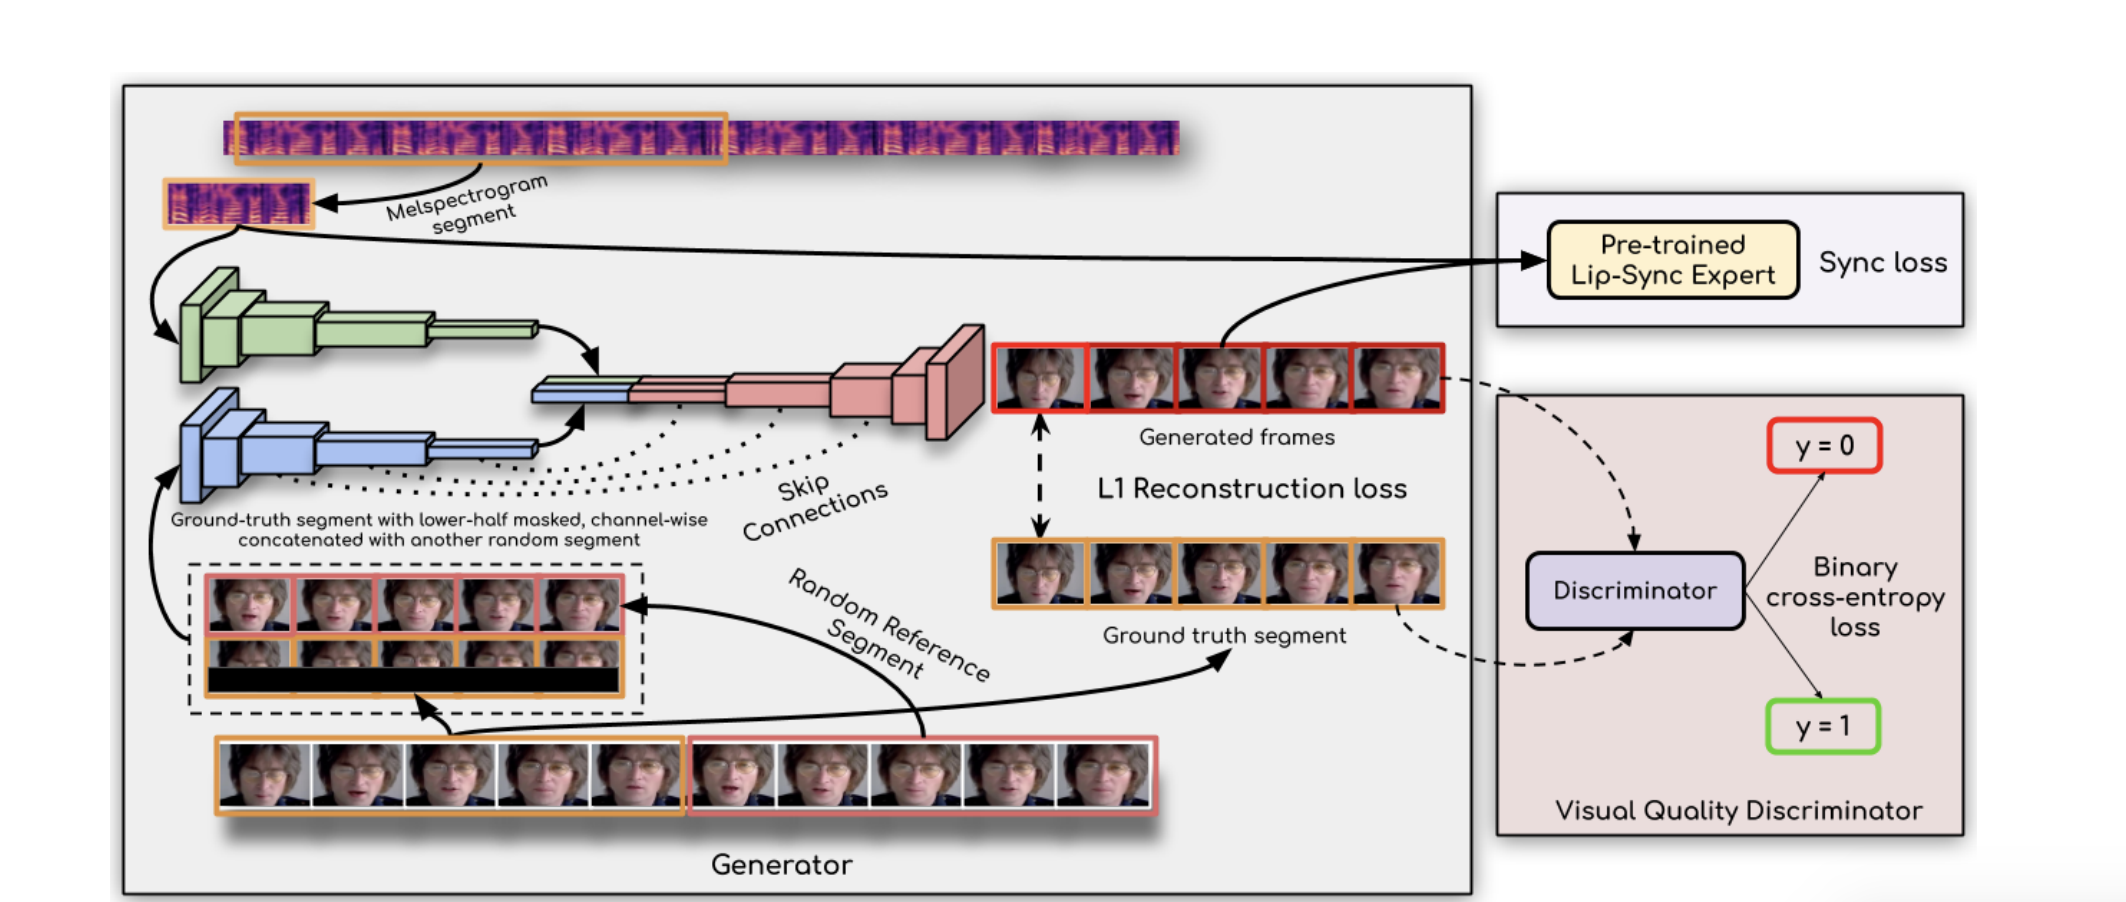
**🔍 What is Wav2Lip?**

Wav2Lip is a deep learning model that can take any speech audio and make a video of someone’s face speak it perfectly, with lip movements that match the audio exactly.

It’s like magic—it can take a mute video of someone and make them speak any voice you give it, even in different languages or accents!

**🎯 Purpose of Wav2Lip**

The main goal of Wav2Lip is to create perfect lip-sync videos. It’s useful for:

1.   Fixing out-of-sync videos – If lips don’t match speech, Wav2Lip can fix it
2.   Dubbing movies or videos – Match lip movements to different languages.
3. Helping in accessibility – E.g., making clear speech videos for people with hearing issues.
4. Deepfake creation or detection research – Used in both creating and spotting fake content.

**🛠️ How It Works (Simplified)**

1. Input:

  * A video of someone’s face (even if they’re not talking).

  * An audio clip of someone speaking (can be any voice).

2. Processing:

  * The model analyzes the audio to understand how the lips should move.

  * It then generates new lip movements on the video, frame by frame, to match the speech.

3. Output:

  * A new video where the person looks like they are actually speaking the audio.





In [ ]:
#@title Dub it!
#@markdown 1. Choose audio (you can also enter a YouTube or similar URL, or a manually uploaded file name):
audio = 'שונאת שמאלנים' #@param ['Dangerous time', 'Go home', 'Sound of victory', 'Ernie and Bert (2 speakers)', '11,780 votes (3 speakers)', 'מלפפונים חמוצים', 'שונאת שמאלנים', 'אני שולה', 'אריק ובנץ (2 דוברים)', 'אריק ובנץ וגנץ (3 דוברים)', 'Grab from uploaded video'] {allow-input: true}
#@markdown 2. Optionally untick "smooth_face_detection" to disable temporal smoothing of face coordinates:
smooth_face_detection = True #@param {type: "boolean"}
#@markdown 3. Optionally tick "override_face_detection" to manually asign face coordinates:
override_face_detection = False #@param {type: "boolean"}
left = 0# @param {type: "integer"}
top = 0# @param {type: "integer"}
width = 1080 #@param {type: "integer"}
height = 1920 #@param {type: "integer"}
#@markdown 4. Optionally tick "switch_speakers" to switch between visual media files with the change of speakers:
switch_speakers = False #@param {type: "boolean"}
#@markdown 5. Choose model for speaker diarization:
model = 'pyannote-audio DIHARD' #@param ['pyAudioAnalysis', 'pyannote-audio DIHARD','pyannote-audio AMI']
#@markdown 6. Optionally tick "reuse_files" to reuse previously uploaded files:
reuse_files = False #@param {type: "boolean"}
#@markdown 7. Press the play (triangle) button on the left.
#@markdown 8. Press "Browse" or "Choose files" below, and upload image(s) or video(s) (if not reusing files).
#@markdown 9. If the resulting videos are too large, the Colab might disconnect, but you may still manually download the .mp4 from the folder on the left (click "Refresh" if missing).

from google.colab import files
try:
  inputs
except NameError:
  reuse_files = False

if not reuse_files:
  %cd /content/sample_data
  !rm -rf *
  inputs = files.upload()

if inputs:
  %cd /content
  !git clone --depth 1 https://github.com/eyaler/Wav2Lip
  import os
  !pip install librosa==0.9.2
  !pip install -U gdown
  if not os.path.exists('/content/Wav2Lip/checkpoints/wav2lip_gan.pth'):
    !gdown https://drive.google.com/uc?id=1dwHujX7RVNCvdR1RR93z0FS2T2yzqup9 -O /content/Wav2Lip/checkpoints/wav2lip_gan.pth
  !wget --no-check-certificate -nc https://eyalgruss.com/fomm/wav2lip_gan.pth -O /content/Wav2Lip/checkpoints/wav2lip_gan.pth
  #!wget --no-check-certificate -nc https://eyalgruss.com/fomm/wav2lip.pth -O /content/Wav2Lip/checkpoints/wav2lip.pth
  !wget --no-check-certificate -nc https://eyalgruss.com/fomm/s3fd-619a316812.pth -O /content/Wav2Lip/face_detection/detection/sfd/s3fd.pth
  !pip install git+https://github.com/ytdl-org/youtube-dl
  grab = False
  manual = False
  if '://' in audio:
    if os.path.exists('/content/custom.mp3'):
      os.remove('/content/custom.mp3')
    !youtube-dl --no-playlist --extract-audio --audio-format mp3 "$audio" -o "/content/custom.%(ext)s"
    audio = 'custom'
  elif audio=='Dangerous time':
    audio = 'dangerous'
    if not os.path.exists('/content/dangerous.mp3'):
      !youtube-dl --no-playlist --extract-audio --audio-format mp3 https://www.youtube.com/watch?v=cQ54GDm1eL0 -o "/content/dangerous.%(ext)s"
  elif audio=='Go home':
    audio = 'gohome'
    !wget --no-check-certificate -nc https://eyalgruss.com/fomm/gohome.mp3
  elif audio=='Sound of victory':
    audio = 'victory'
    if not os.path.exists('/content/victory.mp3'):
      !youtube-dl --no-playlist --extract-audio --audio-format mp3 https://www.youtube.com/watch?v=Nu96Fhl1Gjo -o "/content/victory.%(ext)s"
  elif audio=='Ernie and Bert (2 speakers)':
    audio = 'dialog_eng'
    if not os.path.exists('/content/dialog_eng.mp3'):
      !youtube-dl --no-playlist --extract-audio --audio-format mp3 https://www.youtube.com/watch?v=I78YAciQpr0 -o "/content/dialog_eng.%(ext)s"
  elif audio == '11,780 votes (3 speakers)':
    audio = 'trialog_eng'
    if not os.path.exists('/content/trialog_eng.mp3'):
      !youtube-dl --no-playlist --extract-audio --audio-format mp3 https://www.youtube.com/watch?v=o3hrN0cP58Y -o "/content/trialog_heb.%(ext)s"
  elif audio == 'מלפפונים חמוצים':
    audio = 'melaflefon'
    !wget --no-check-certificate -nc https://eyalgruss.com/fomm/melaflefon.mp3
  elif audio == 'שונאת שמאלנים':
    audio = 'sonet'
    !wget --no-check-certificate -nc https://eyalgruss.com/fomm/sonet.mp3
  elif audio == 'אני שולה':
    audio = 'shoula'
    !wget --no-check-certificate -nc https://eyalgruss.com/fomm/shoula.mp3
  elif audio == 'אריק ובנץ (2 דוברים)':
    audio = 'dialog_heb'
    if not os.path.exists('/content/dialog_heb.mp3'):
      !youtube-dl --no-playlist --extract-audio --audio-format mp3 https://www.youtube.com/watch?v=rrZ3bo4VmpQ -o "/content/dialog_heb.%(ext)s"
  elif audio == 'אריק ובנץ וגנץ (3 דוברים)':
    audio = 'trialog_heb'
    if not os.path.exists('/content/trialog_heb.mp3'):
      !youtube-dl --no-playlist --extract-audio --audio-format mp3 https://www.youtube.com/watch?v=HOKJnkG5MXQ -o "/content/trialog_heb.%(ext)s"
  elif audio == 'Grab from uploaded video':
    grab = True
  elif audio == '':
    audio = 'custom'
  else:
    manual = True
  audio = '/content/'+audio
  if manual:
    for ext in ['mp3','wav','m4a','aac','ogg','flac','wma','aiff','opus','amr','ac3','mp4']:
      if os.path.exists(audio+'.'+ext):
        audio += '.'+ext
        break
      if os.path.exists(audio+'.'+ext.upper()):
        audio += '.'+ext.upper()
        break
  else:
    audio += '.mp3'
  assert grab or os.path.exists(audio), 'Error: could not find audio file: '+audio

  %cd /content/Wav2Lip
  outputs = []
  for im in list(inputs):
    !rm -rf /content/Wav2Lip/temp/*
    infile = '/content/sample_data/'+im
    ext = infile.rsplit('.',1)[1]
    if ext != ext.lower() or "'" in infile or ' ' in infile:
      ext = ext.lower()
      lower = infile.rsplit('.',1)[0].replace("'",'').replace(' ','_')+'.'+ext
      !rm -rf "$lower"
      os.rename(infile, lower)
      infile = lower
      data = inputs.pop(im)
      im = infile.rsplit('/',1)[1]
      inputs[im] = data
    outfile = '/content/'+im.rsplit('.',1)[0]+'_out.mp4'
    !rm -rf "$outfile"
    if grab:
      audio = infile
    elif "'" in audio:
      fix = audio.replace("'",'').replace(' ','_')
      !rm -rf "$fix"
      os.rename(audio, fix)
      audio = fix
    if not override_face_detection:
      nosmooth = '' if smooth_face_detection else '--nosmooth'
      !python inference.py --checkpoint_path checkpoints/wav2lip_gan.pth --face "$infile" --audio \"\"$audio\"\" --pads 0 20 0 0 $nosmooth --outfile \"\"$outfile\"\"
    if override_face_detection or os.path.exists('/content/Wav2Lip/temp/faulty_frame.jpg'):
      import cv2
      if override_face_detection:
        print('\nOverriding face detection')
      else:
        print('\nFace not detected - will use whole frame')
      if ext in ['jpg', 'png', 'jpeg']:
        frame = cv2.imread(infile)
      else:
        video_stream = cv2.VideoCapture(infile)
        still_reading, frame = video_stream.read()
      y2,x2 = frame.shape[:2]
      if override_face_detection:
        x1 = left
        y1 = top
        x2 = min(left+width, x2)
        y2 = min(top+height, y2)
      else:
        x1 = y1 = 0
        if x2>y2:
          x1 = (x2-y2)//2
          x2 = x1+y2
      !python inference.py --checkpoint_path checkpoints/wav2lip_gan.pth --face "$infile" --audio \"\"$audio\"\" --box $y1 $y2 $x1 $x2 --pads 0 20 0 0 --outfile \"\"$outfile\"\"
    outputs.append(outfile)

  wav = None
  if switch_speakers and len(outputs)>1 and not grab:
    wav = audio.rsplit('.',1)[0]+'.wav'
    !ffmpeg -i "$audio" "$wav" -y
    min_dt = 0.5
    if model.startswith('pyannote-audio'):
      !pip install pyannote.core==4.1 pyannote.pipeline==1.5.2 pyannote.audio==1.1.1
      !wget -nc https://raw.githubusercontent.com/pyannote/pyannote-audio/1.1.1/hubconf.py -P /root/.cache/torch/hub/pyannote_pyannote-audio_main
      import torch
      import pyannote.core  # See: https://github.com/pyannote/pyannote-audio/issues/561
      from pyannote.audio.features.utils import get_audio_duration
      if model.endswith('AMI'):
        pipeline = torch.hub.load('pyannote/pyannote-audio', 'dia_ami', trust_repo=True)
      else:
        pipeline = torch.hub.load('pyannote/pyannote-audio', 'dia', trust_repo=True)
      cls = pipeline({'audio':wav})
      tmp_segs = [((s.start,s.end),l) for s,_,l in cls.itertracks(yield_label=True)]
      segs = []
      prev_ind = None
      prev_start = None
      for (start,end),ind in tmp_segs+[((get_audio_duration({'audio':wav}),None),None)]:
        if ind!=prev_ind:
          if prev_ind is not None:
            segs.append([(prev_start,start),prev_ind])
          prev_ind = ind
          prev_start = start
    elif model=='pyAudioAnalysis':
      !pip install hmmlearn==0.2.8
      !pip install eyeD3==0.9.5
      !pip install pydub==0.24.0
      !pip install pyAudioAnalysis==0.3.14
      from pyAudioAnalysis import audioSegmentation as aS
      mid_window=2
      mid_step=0.2
      short_window=0.05
      lda_dim=0 #35
      cls = aS.speaker_diarization(wav, len(outputs), mid_window=mid_window, mid_step=mid_step, short_window=short_window, lda_dim=lda_dim)[0]
      segs = list(zip(*aS.labels_to_segments(cls, mid_step)))
    deleted = 0
    unified = 0
    if min_dt:
      for i in range(len(segs)-1,0,-1):
        if segs[i][0][1]-segs[i][0][0]<min_dt:
          if i+1<len(segs) and segs[i-1][1] == segs[i+1][1]:
            segs[i-1] = ((segs[i-1][0][0],segs[i+1][0][1]),segs[i-1][1])
            del segs[i+1]
            unified += 1
          else:
            segs[i-1] = ((segs[i-1][0][0],segs[i][0][1]),segs[i-1][1])
          del segs[i]
          deleted += 1
    inds = {}
    my_ind = 0
    with open('/content/list.txt','w',encoding='utf8') as f:
      for i,((start,end),ind) in enumerate(segs):
        if ind not in inds:
          inds[ind] = my_ind%len(outputs)
          my_ind += 1
        f.write("file '%s'\n"%outputs[inds[ind]])
        if i>0:
          f.write('inpoint %f\n'%start)
        if i<len(segs)-1:
          f.write('outpoint %f\n'%end)
    !ffmpeg -f concat -safe 0 -i /content/list.txt -i "{outputs[0]}" -map 0:v -map 1:a -c:v libx264 -c:a aac -vf "crop=trunc(iw/2)*2:trunc(ih/2)*2" -pix_fmt yuv420p -profile:v baseline -movflags +faststart /content/combined.mp4 -y
    new_outputs = ['/content/combined.mp4']
    if len(outputs)==2:
      with open('/content/list2.txt','w',encoding='utf8') as f:
        for i,((start,end),ind) in enumerate(segs):
          f.write("file '%s'\n"%outputs[1-inds[ind]])
          if i>0:
            f.write('inpoint %f\n'%start)
          if i<len(segs)-1:
            f.write('outpoint %f\n'%end)
      !ffmpeg -f concat -safe 0 -i /content/list2.txt -i "{outputs[1]}" -map 0:v -map 1:a -c:v libx264 -c:a aac -vf "crop=trunc(iw/2)*2:trunc(ih/2)*2" -pix_fmt yuv420p -profile:v baseline -movflags +faststart /content/combined2.mp4 -y
      new_outputs.append('/content/combined2.mp4')
    outputs = new_outputs

  from IPython.display import HTML, clear_output
  from base64 import b64encode

  clear_output()
  print('if video does not show below, you can still download it!')
  if wav:
    print('speakers=%d segments=%d deleted=%d unified=%d'%(len(inds), len(segs),deleted,unified))
  muted = 'muted'

  for i,file in enumerate(reversed(outputs)):
    if i==len(outputs)-1:
      muted = ''
    try:
      with open(file, 'rb') as f:
        data_url = "data:video/mp4;base64," + b64encode(f.read()).decode()
      display(HTML("""
      <video width=600 controls autoplay loop %s>
            <source src="%s" type="video/mp4">
      </video>""" % (muted,data_url)))
    except Exception:
      pass
  if wav:
    print('speakers=%d segments=%d deleted=%d unified=%d'%(len(inds), len(segs),deleted,unified))
  for file in outputs:
    try:
      files.download(file)
    except Exception:
      pass